# Домашняя работа. Метрики магазина «Мякушка»

«Мякушка» — сеть пекарен, которая продаёт хлеб и выпечку через приложение и сайт. Магазин работает в нескольких городах России. Пользователи заходят в приложение, просматривают товары и оформляют заказы.

Команда «Мякушки» готовит отчёт за июнь 2026 года. Вам передали выгрузку пользовательских событий и попросили подготовить короткий аналитический отчёт: посчитать показатели за месяц, исследовать динамику revenue по городам и сравнить покупателей Москвы и Казани.

Домашняя работа состоит из **трёх обязательных заданий и одного дополнительного**. В каждом задании оставьте код, результат его выполнения и ответ на вопрос задания.

## Ход исследования

Исследование пройдёт в три этапа:

- расчёт месячных показателей
- анализ подневной динамики revenue по городам
- сравнение покупателей Москвы и Казани

Выполните расчёты и оставьте после каждого этапа короткий вывод. Код должен запускаться последовательно без ошибок.

## Начало работы

Импортируйте библиотеки. Затем найдите файл `myakushka_events.csv`, скопируйте путь к нему и вставьте внутрь кавычек в следующей ячейке.

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [97]:
data_path = "myakushka_events.csv"

df = pd.read_csv(data_path)
df.head()

,event_timestamp,user_id,city,event_type,order_id,revenue,source,platform
0,2026-06-01 02:01:45,TEST-KZN-0001,Казань,purchase,TEST-00001,unknown,test,android
1,2026-06-01 02:01:49,TEST-KZN-0121,Казань,purchase,TEST-00121,110.00,test,android
2,2026-06-01 02:31:18,TEST-KZN-0031,Казань,purchase,TEST-00031,110.00,test,android
3,2026-06-01 03:01:47,TEST-KZN-0061,Казань,purchase,TEST-00061,110.00,test,ios
4,2026-06-01 03:31:47,TEST-KZN-0091,Казань,purchase,TEST-00091,110.00,test,android


## Структура данных

Одна строка таблицы — одно событие пользователя в приложении.

| Столбец | Содержание |
|---|---|
| `event_timestamp` | дата и время события |
| `user_id` | идентификатор пользователя |
| `city` | город пользователя |
| `event_type` | тип события: визит, просмотр товара или покупка |
| `order_id` | идентификатор заказа; заполнен для событий покупки |
| `revenue` | выручка; для событий без покупки обычно равна 0 |
| `source` | канал привлечения или служебная метка: `organic`, `ads`, `referral`, `test` |
| `platform` | платформа: Android, iOS или web |

О качестве данных ничего не известно. Перед расчётами убедитесь, что столбцы, необходимые для анализа, заполнены и имеют подходящий формат.

## Задание 1. Посчитайте показатели за месяц

Рассчитайте четыре показателя магазина за июнь:

- **Revenue** — выручка магазина от покупок
- **MAU** — количество пользователей, которые хотя бы раз заходили в приложение за месяц
- **Buyers** — количество пользователей, которые хотя бы раз совершили покупку за месяц
- **Orders** — количество оформленных заказов за месяц

Перед расчётом посмотрите на столбцы, от которых зависят эти показатели, и проверьте, всё ли в порядке с их качеством. Подготовьте данные так, чтобы найденные проблемы не искажали итоговые значения.

In [98]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10772 entries, 0 to 10771
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   event_timestamp  10772 non-null  object
 1   user_id          10772 non-null  object
 2   city             10772 non-null  object
 3   event_type       10772 non-null  object
 4   order_id         1326 non-null   object
 5   revenue          10772 non-null  object
 6   source           10772 non-null  object
 7   platform         10772 non-null  object
dtypes: object(8)
memory usage: 673.4+ KB


,event_timestamp,user_id,city,event_type,order_id,revenue,source,platform
0,2026-06-01 02:01:45,TEST-KZN-0001,Казань,purchase,TEST-00001,unknown,test,android
1,2026-06-01 02:01:49,TEST-KZN-0121,Казань,purchase,TEST-00121,110.00,test,android
2,2026-06-01 02:31:18,TEST-KZN-0031,Казань,purchase,TEST-00031,110.00,test,android
3,2026-06-01 03:01:47,TEST-KZN-0061,Казань,purchase,TEST-00061,110.00,test,ios
4,2026-06-01 03:31:47,TEST-KZN-0091,Казань,purchase,TEST-00091,110.00,test,android


In [99]:
print(df.isnull().sum())
print("")
print(df.duplicated().sum())    

event_timestamp       0
user_id               0
city                  0
event_type            0
order_id           9446
revenue               0
source                0
platform              0
dtype: int64

0


In [100]:
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df = df[df['source'] != 'test'].copy()
df.sample(5)

,event_timestamp,user_id,city,event_type,order_id,revenue,source,platform
10578,2026-06-30 13:32:55,KZN-0047,Казань,visit,NaN,0.0,organic,ios
5451,2026-06-16 11:50:57,EKB-0106,Екатеринбург,visit,NaN,0.0,organic,android
3916,2026-06-12 08:19:22,NSK-0027,Новосибирск,product_view,NaN,0.0,organic,web
7836,2026-06-22 17:29:09,SPB-0167,Санкт-Петербург,product_view,NaN,0.0,ads,ios
2484,2026-06-07 18:11:05,SPB-0088,Санкт-Петербург,visit,NaN,0.0,organic,web


In [101]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 10642 entries, 5 to 10771
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   event_timestamp  10642 non-null  datetime64[ns]
 1   user_id          10642 non-null  object        
 2   city             10642 non-null  object        
 3   event_type       10642 non-null  object        
 4   order_id         1196 non-null   object        
 5   revenue          10642 non-null  float64       
 6   source           10642 non-null  object        
 7   platform         10642 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 748.3+ KB


,event_timestamp,user_id,city,event_type,order_id,revenue,source,platform
5,2026-06-01 08:03:46,NSK-0009,Новосибирск,visit,NaN,0.0,ads,android
6,2026-06-01 08:08:18,NSK-0009,Новосибирск,product_view,NaN,0.0,ads,android
7,2026-06-01 08:11:12,SPB-0071,Санкт-Петербург,visit,NaN,0.0,referral,android
8,2026-06-01 08:15:32,NSK-0020,Новосибирск,visit,NaN,0.0,organic,android
9,2026-06-01 08:17:25,KZN-0010,Казань,visit,NaN,0.0,ads,android


### Обоснование подготовки данных

Можем заметить, что ревеня типа объект, сделаем его числом с плавуещей точкой(все unknow стали NaN).
Также удалим тестовые данные(иначе будет искажение показателей).
Переведем дату в тип даты.
Пропусков и дубликатов нет.
Пропуски в order_id для событий без покупки не проблемой, потому что идентификатор заказа нужен только для событий purchase.

In [102]:
# посчитаем итоговые показаетли

# чтобы проанализировать данные, нужно выделить события покупки,
# так как они являются ключевыми для расчета метрик
purchases = df[df['event_type'] == 'purchase'].copy()
display(purchases.head())

# посчитаем общую выручку, MAU, Buyers, Orders
revenue = purchases['revenue'].sum()
mau = df.loc[df['event_type'] == 'visit', 'user_id'].nunique()
buyers = purchases['user_id'].nunique()
orders = purchases['order_id'].nunique()

,event_timestamp,user_id,city,event_type,order_id,revenue,source,platform
46,2026-06-01 10:08:18,EKB-0017,Екатеринбург,purchase,ORD-000032,290.0,organic,web
49,2026-06-01 10:09:24,SPB-0043,Санкт-Петербург,purchase,ORD-000020,650.0,organic,ios
59,2026-06-01 10:31:51,MSK-0031,Москва,purchase,ORD-000005,230.0,organic,android
72,2026-06-01 11:09:37,SPB-0027,Санкт-Петербург,purchase,ORD-000019,350.0,organic,android
78,2026-06-01 11:23:37,SPB-0045,Санкт-Петербург,purchase,ORD-000015,270.0,organic,ios


### Выводы

Выведите итоговые показатели Revenue, MAU, Buyers и Orders

In [103]:
print('Revenue: ', revenue)
print('MAU: ', mau)
print('Buyers: ', buyers)
print('Orders: ', orders)

Revenue:  505120.0
MAU:  882
Buyers:  221
Orders:  1196


## Задание 2. Найдите города с наибольшим ростом revenue

Исследуйте, как менялась revenue в течение месяца в разных городах. Постройте **один** chart с подневной revenue и разбивкой по городам. Затем выберите сопоставимые периоды в начале и в конце месяца и для **каждого города** рассчитайте:

- суммарную revenue за период в начале месяца
- суммарную revenue за период в конце месяца
- абсолютное изменение revenue
- относительное изменение revenue

Относительное изменение считайте по формуле `(revenue_end - revenue_start) / revenue_start`. Определите, какой город лидирует по абсолютному росту, а какой — по относительному, и объясните, почему ответы могут различаться.

In [104]:
purchases = df[df['event_type'] == 'purchase'].copy()
purchases['date'] = purchases['event_timestamp'].dt.date
purchases.head()


,event_timestamp,user_id,city,event_type,order_id,revenue,source,platform,date
46,2026-06-01 10:08:18,EKB-0017,Екатеринбург,purchase,ORD-000032,290.0,organic,web,2026-06-01
49,2026-06-01 10:09:24,SPB-0043,Санкт-Петербург,purchase,ORD-000020,650.0,organic,ios,2026-06-01
59,2026-06-01 10:31:51,MSK-0031,Москва,purchase,ORD-000005,230.0,organic,android,2026-06-01
72,2026-06-01 11:09:37,SPB-0027,Санкт-Петербург,purchase,ORD-000019,350.0,organic,android,2026-06-01
78,2026-06-01 11:23:37,SPB-0045,Санкт-Петербург,purchase,ORD-000015,270.0,organic,ios,2026-06-01


In [105]:
daily_revenue = purchases.groupby(['date', 'city'], as_index=False)['revenue'].sum()
display(daily_revenue.head(5))

,date,city,revenue
0,2026-06-01,Екатеринбург,1790.0
1,2026-06-01,Казань,1740.0
2,2026-06-01,Москва,3380.0
3,2026-06-01,Новосибирск,990.0
4,2026-06-01,Санкт-Петербург,3220.0


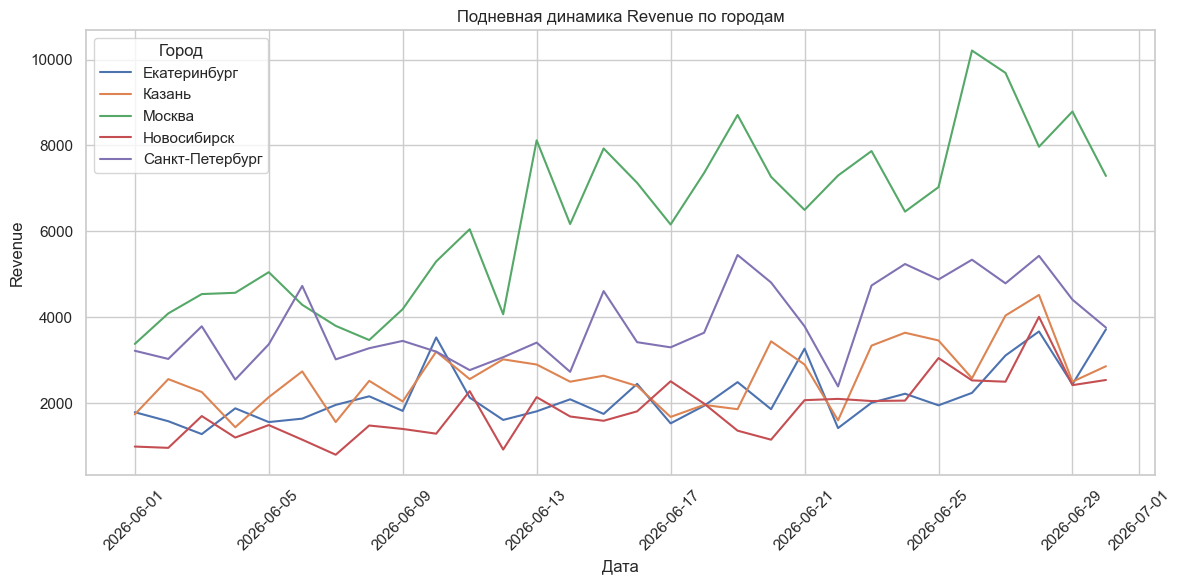

In [106]:
# изобразим chart с подневной динамикой Revenue по городам
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_revenue, x='date', y='revenue', hue='city')
plt.title('Подневная динамика Revenue по городам')
plt.xlabel('Дата')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Город')
plt.tight_layout()
plt.show()

In [107]:
# разделим месяц на три периода: начало, середина и конец месяца
purchases['day'] = purchases['event_timestamp'].dt.day
purchases['period'] = purchases['day'].apply(
    lambda x: 'start' if x <= 7 else ('end' if x >= 24 else 'middle'))
purchases.head()

,event_timestamp,user_id,city,event_type,order_id,revenue,source,platform,date,day,period
46,2026-06-01 10:08:18,EKB-0017,Екатеринбург,purchase,ORD-000032,290.0,organic,web,2026-06-01,1,start
49,2026-06-01 10:09:24,SPB-0043,Санкт-Петербург,purchase,ORD-000020,650.0,organic,ios,2026-06-01,1,start
59,2026-06-01 10:31:51,MSK-0031,Москва,purchase,ORD-000005,230.0,organic,android,2026-06-01,1,start
72,2026-06-01 11:09:37,SPB-0027,Санкт-Петербург,purchase,ORD-000019,350.0,organic,android,2026-06-01,1,start
78,2026-06-01 11:23:37,SPB-0045,Санкт-Петербург,purchase,ORD-000015,270.0,organic,ios,2026-06-01,1,start


In [108]:
comparison_revenue = purchases[purchases['period'].isin(['end', 'start'])].groupby(['city', 'period'])['revenue'].sum().unstack()
display(comparison_revenue)

period,end,start
city,,
Екатеринбург,19350.0,11690.0
Казань,23600.0,14440.0
Москва,57440.0,29720.0
Новосибирск,19110.0,8290.0
Санкт-Петербург,33850.0,23710.0


In [109]:
comparison_revenue['abs_diff'] = comparison_revenue['end'] - comparison_revenue['start']
comparison_revenue['rel_diff%'] = comparison_revenue['abs_diff'] / comparison_revenue['start'] * 100
display(comparison_revenue)

period,end,start,abs_diff,rel_diff%
city,,,,
Екатеринбург,19350.0,11690.0,7660.0,65.526091
Казань,23600.0,14440.0,9160.0,63.434903
Москва,57440.0,29720.0,27720.0,93.270525
Новосибирск,19110.0,8290.0,10820.0,130.518697
Санкт-Петербург,33850.0,23710.0,10140.0,42.766765


### Обоснование выбора периодов

_Укажите границы периодов и объясните, почему их корректно сравнивать._

Выбраны периоды 1–7 июня и 24–30 июня. Оба периода по 7 календарных дней, содержат одинаковое количество будних (5) и выходных (2) дней. Это делает сравнение корректным: разница в выручке не объясняется разной длиной периода или разным соотношением будней и выходных.

### Выводы

*Назовите лидеров абсолютного и относительного роста. Объясните, почему эти показатели могут указывать на разные города*

По абсолютному изменению лидирует Москва: revenue выросла с 29720 до 57440, то есть на 27720; а по относительному - Новосибирск: revenue выросла с 8290 до 19110, что соответствует росту примерно на 130,5%.
Показатели указывают на разные города, потому что абсолютный рост сильно зависит от размера базы: у Москвы уже в начале месяца выручка была почти в 3,5 раза больше, чем у Новосибирска, поэтому даже умеренный процентный прирост даёт большой рублёвый эффект. Новосибирск же стартовал с небольшой базы, и его рост в процентах выглядит более впечатляющим. По относительному росту можно сравнивать "скорость" развития, по абсолютному - "вклад в общий оборот".

## Задание 3. Сравните покупателей Москвы и Казани

Сравните поведение пользователей Москвы и Казани, которые совершили хотя бы одну покупку за месяц.

Для каждого покупателя рассчитайте revenue за месяц и количество визитов. Затем сравните города по двум показателям:

- средняя revenue на покупателя
- среднее количество визитов в приложение на покупателя

Чтобы описать различия подробнее, для каждой пользовательской метрики рассчитайте среднее, медиану, дисперсию, 25-й и 75-й квантили, минимум и максимум. При желании дополните описание гистограммами или boxplot-ами.

Опишите, какие различия между покупателями Москвы и Казани вы обнаружили.

In [135]:
# функция для расчета статистики
def get_stats(grop):
    return pd.Series({
        'mean': grop.mean(),
        'median': grop.median(),
        'var': grop.var(),
        'quartile_25': grop.quantile(0.25),
        'quartile_75': grop.quantile(0.75),
        'min': grop.min(),
        'max': grop.max()
    })

In [128]:
purchases = df[df['event_type'] == 'purchase'].copy()
buyer_revenue = purchases.groupby(['city', 'user_id'], as_index=False)['revenue'].sum()
buyer_revenue.head()

,city,user_id,revenue
0,Екатеринбург,EKB-0001,4940.0
1,Екатеринбург,EKB-0002,1990.0
2,Екатеринбург,EKB-0003,1610.0
3,Екатеринбург,EKB-0004,3480.0
4,Екатеринбург,EKB-0005,2820.0


In [129]:
buyer_visits = df[df['event_type'] == 'visit'].groupby(['city', 'user_id']).size().reset_index(name='visits_count')
buyer_visits.head()

,city,user_id,visits_count
0,Екатеринбург,EKB-0001,11
1,Екатеринбург,EKB-0002,9
2,Екатеринбург,EKB-0003,9
3,Екатеринбург,EKB-0004,11
4,Екатеринбург,EKB-0005,9


In [138]:
buyers = buyer_revenue.merge(buyer_visits, on=['city', 'user_id'], how='left')
buyers['visits_count'] = buyers['visits_count'].fillna(0)
buyers = buyers[buyers['city'].isin(['Москва', 'Казань'])]
buyers.head()

,city,user_id,revenue,visits_count
30,Казань,KZN-0001,4540.0,13
31,Казань,KZN-0002,1000.0,9
32,Казань,KZN-0003,1460.0,10
33,Казань,KZN-0004,3140.0,11
34,Казань,KZN-0005,5980.0,12


In [139]:
stats_revenue = buyers.groupby('city')['revenue'].apply(get_stats).unstack()
display(stats_revenue)

,mean,median,var,quartile_25,quartile_75,min,max
city,,,,,,,
Казань,2245.714286,2300.0,1.372790e+06,1360.0,2900.0,480.0,5980.0
Москва,2543.466667,2250.0,1.877869e+06,1420.0,3535.0,230.0,7040.0


In [140]:
stats_visits = buyers.groupby('city')['visits_count'].apply(get_stats).unstack()
display(stats_visits)

,mean,median,var,quartile_25,quartile_75,min,max
city,,,,,,,
Казань,8.857143,8.0,7.184874,7.0,11.0,4.0,14.0
Москва,9.320000,9.0,7.328649,7.5,11.0,3.0,17.0


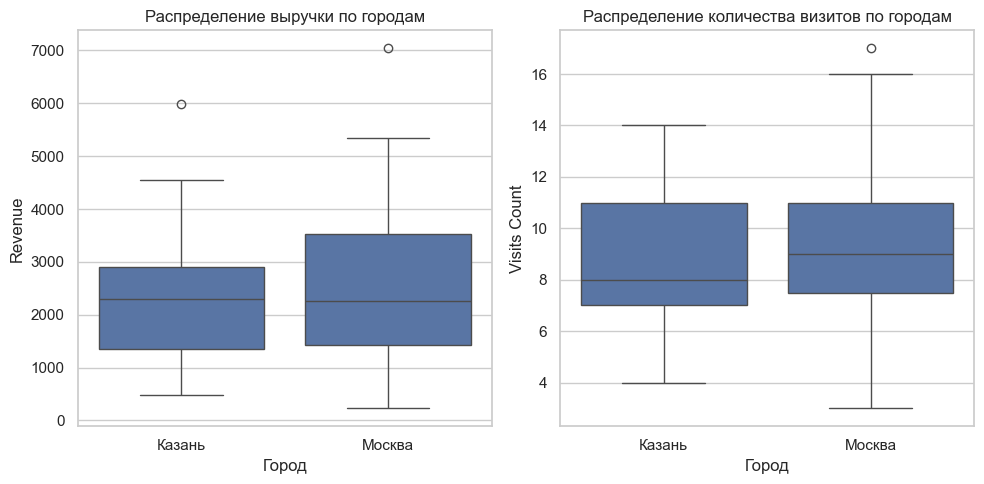

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(data=buyers, x='city', y='revenue', ax=axes[0])
axes[0].set_title('Распределение выручки по городам')
axes[0].set_xlabel('Город')
axes[0].set_ylabel('Revenue')

sns.boxplot(data=buyers, x='city', y='visits_count', ax=axes[1])
axes[1].set_title('Распределение количества визитов по городам')
axes[1].set_xlabel('Город')
axes[1].set_ylabel('Visits_count')  

plt.tight_layout()
plt.show()

### Выводы

*Сравните покупателей двух городов по двум метрикам. Какие выводы о различиях и сходствах распределений вы можете сделать? В описании сравните средние, медианы и ширину распределений (не обязательно использовать все параметры, акцентируйте внимание на интересных по вашему мнению моментах)*

Средняя revenue на покупателя в Москве составляет 2543,47, а в Казани - 2245,71. Медиана revenue немного выше в Казани: 2300 > 2250 (в Москве). Это показывает, что среднее значение в Москве сильнее зависит от покупателей с высокой выручкой. Максимальная revenue в Москве также выше: 7040 > 5980 (в Казани). Разброс revenue в Москве больше: дисперсия составляет около 1,88 млн > 1,37 млн (в Казани). Следовательно, суммы покупок московских покупателей распределены более неоднородно. По количеству визитов различия меньше. Среднее количество визитов составляет 9,32 в Москве и 8,86 в Казани, а медиана - 9 и 8 соответственно. При этом 75 процентиль в обоих городах равен 11 визитам, поэтому верхняя часть распределений достаточно похожа.

Таким образом, покупатели Москвы в среднем имеют немного больше визитов и более высокую среднюю revenue, однако медианная revenue немного выше в Казани. Это говорит о том, что различие в средней выручке частично связано с несколькими покупателями с высокими значениями revenue в Москве.

## Задание 4 (дополнительное). Есть ли связь между активностью пользователя и revenue?

Команда «Мякушки» хочет понять, связана ли активность пользователя в приложении с revenue.

В этом задании рассматривайте всех пользователей, которые хотя бы раз заходили в приложение за месяц.

- Постройте scatter plot количества визитов и revenue каждого пользователя
- Рассчитайте коэффициент корреляции Пирсона
- Проинтерпретируйте полученные результаты и ответьте на вопрос команды, обозначив ограничения анализа

In [161]:
user_visits = df[df['event_type'] == 'visit'].groupby('user_id').size().reset_index(name='visits_count')
user_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 882 entries, 0 to 881
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       882 non-null    object
 1   visits_count  882 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.9+ KB


In [160]:
user_revenue = purchases.groupby('user_id')['revenue'].sum().reset_index()
user_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  221 non-null    object 
 1   revenue  221 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.6+ KB


In [157]:
user_analysis = user_visits.merge(user_revenue, on='user_id', how='left')
user_analysis['revenue'] = user_analysis['revenue'].fillna(0)
display(user_analysis.head())
user_analysis.info()

,user_id,visits_count,revenue
0,EKB-0001,11,4940.0
1,EKB-0002,9,1990.0
2,EKB-0003,9,1610.0
3,EKB-0004,11,3480.0
4,EKB-0005,9,2820.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 882 entries, 0 to 881
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       882 non-null    object 
 1   visits_count  882 non-null    int64  
 2   revenue       882 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 20.8+ KB


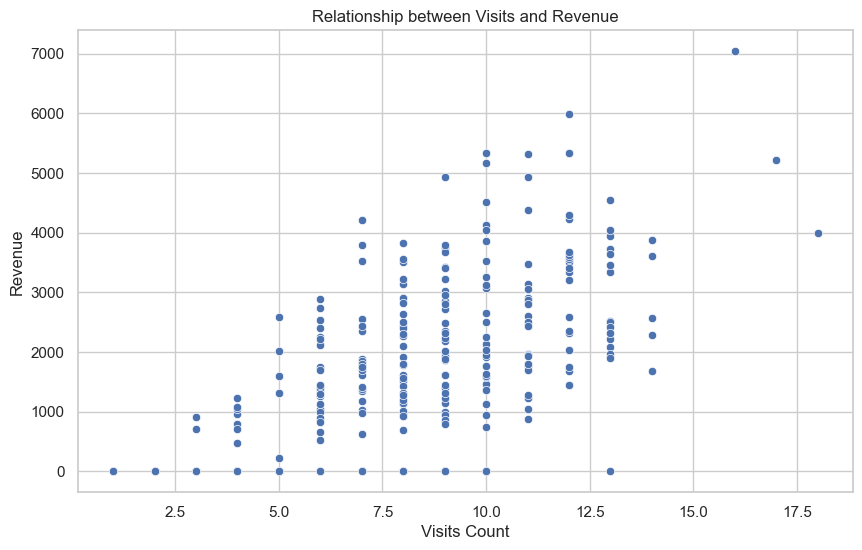

In [158]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=user_analysis, x='visits_count', y='revenue')
plt.xlabel('Visits Count')
plt.ylabel('Revenue')
plt.title('Relationship between Visits and Revenue')
plt.show()

In [162]:
correlation = user_analysis['visits_count'].corr(user_analysis['revenue'], method='pearson')
print(f'Correlation between Visits Count and Revenue: {correlation}')

Correlation between Visits Count and Revenue: 0.6829287433801063


### Выводы

*Напишите вывод здесь*

По 882 пользователям, которые хотя бы раз заходили в приложение за месяц, была рассчитана связь между количеством визитов и месячной revenue. Коэффициент корреляции Пирсона составил 0,68. Это говорит о слабой положительной связи между активностью пользователя и revenue: в среднем пользователи с большим количеством визитов имеют более высокую выручку. При этом корреляция не означает причинно-следственную связь. По этим данным нельзя утверждать, что увеличение количества визитов само по себе приводит к росту revenue. На результаты могут влиять другие факторы, например особенности пользователей, их потребности и склонность к покупкам. Корреляция чувствительна к выбросам и не показывает, как именно меняется revenue при каждом дополнительном визите.

Таким образом, данные показывают слабую положительную связь между активностью пользователей и revenue.